In [4]:
import csv
import matplotlib.pyplot as plt

In [5]:
!apt-get -qq install -y fonts-cmu > /dev/null
import glob
import matplotlib
import matplotlib.font_manager as fm
for fp in glob.glob("/usr/share/fonts/truetype/cmu/cmun*.ttf"):
    fm.fontManager.addfont(fp)
matplotlib.rcParams['font.family'] = 'CMU Serif'
matplotlib.rcParams['axes.unicode_minus'] = False

In [6]:
ARQUIVO = "Aglomeracoes_Turismo_RAIS_2025_Sintese_.csv"
COL_ICT = 9      # 9 = estabelecimentos | 5 = vinculos | 13 = massa de rendimentos
CORTE   = 1.0
DPI     = 300

Tabela 1 - Norte: 2 municípios -> Tabela1_turismo_norte.png


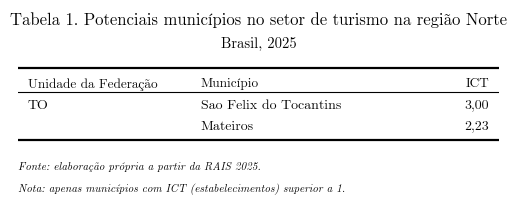

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tabela 2 - Nordeste: 29 municípios -> Tabela2_turismo_nordeste.png


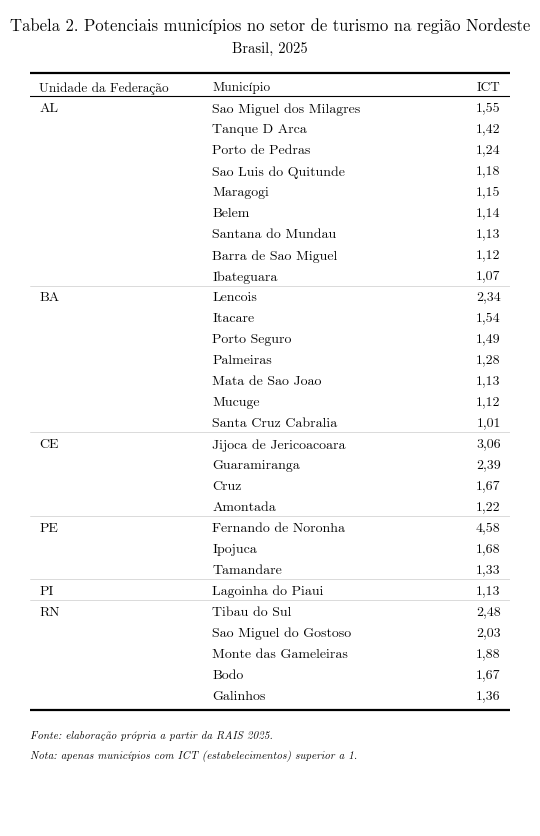

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tabela 3 - Sudeste: 29 municípios -> Tabela3_turismo_sudeste.png


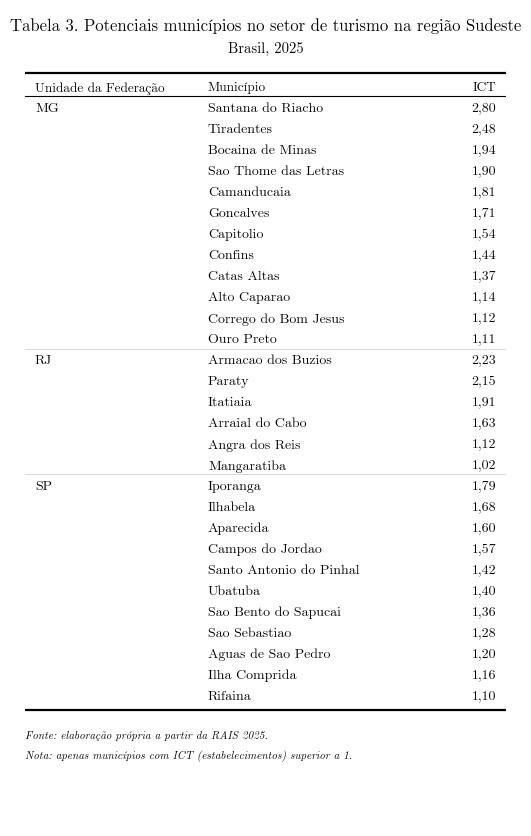

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tabela 4 - Sul: 6 municípios -> Tabela4_turismo_sul.png


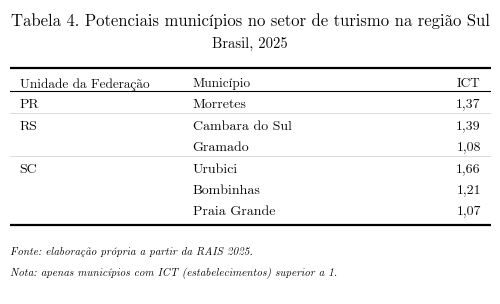

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tabela 5 - Centro-Oeste: 4 municípios -> Tabela5_turismo_centro_oeste.png


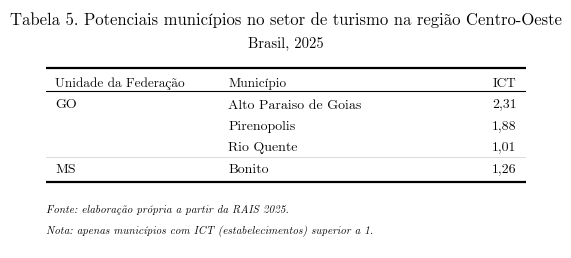

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
REGIOES = {
    "Norte":        ["AC","AP","AM","PA","RO","RR","TO"],
    "Nordeste":     ["AL","BA","CE","MA","PB","PE","PI","RN","SE"],
    "Sudeste":      ["ES","MG","RJ","SP"],
    "Sul":          ["PR","RS","SC"],
    "Centro-Oeste": ["DF","GO","MT","MS"],
}
UF2REG = {uf: reg for reg, ufs in REGIOES.items() for uf in ufs}

PREPS = {'de','do','da','dos','das','e'}
tc = lambda s: ' '.join(w if w in PREPS else w.capitalize() for w in s.lower().split())
def num(s):
    s = s.strip().replace('%','').replace('.','').replace(',','.')
    try: return float(s)
    except: return None

linhas = []
with open(ARQUIVO, encoding="utf-8-sig") as f:
    for r in csv.reader(f, delimiter=';'):
        if len(r) <= COL_ICT: continue
        mun = r[1].strip()
        if not mun or mun == 'BRASIL': continue
        uf, _, nome = mun.partition('-')
        v = num(r[COL_ICT])
        if v is None or v <= CORTE: continue
        linhas.append((uf.strip(), tc(nome.strip()), v))

def tabela(rows, titulo, subtitulo, notas, saida, dpi=300):
    n = len(rows)
    fig, ax = plt.subplots(figsize=(6.2, 1.9 + 0.30*n)); ax.axis('off')
    lh = 0.90/(n+6); y = 0.99
    xu, xm, xi = 0.02, 0.38, 0.98

    ax.text(.5, y, titulo, ha='center', va='top', fontsize=12, fontweight='bold'); y -= lh*1.15
    ax.text(.5, y, subtitulo, ha='center', va='top', fontsize=10.5); y -= lh*1.45
    ax.plot([0,1], [y, y], color='k', lw=1.6, transform=ax.transAxes); y -= lh*0.45

    for x, t, a in [(xu, "Unidade da Federação", 'left'),
                    (xm, "Município", 'left'),
                    (xi, "ICT", 'right')]:
        ax.text(x, y, t, ha=a, va='top', fontsize=9.5, fontweight='bold')
    y -= lh
    ax.plot([0,1], [y+lh*0.35]*2, color='k', lw=0.8, transform=ax.transAxes)

    last = None
    for uf, nome, v in rows:
        if uf != last and last is not None:
            ax.plot([0,1], [y+lh*0.30]*2, color='0.75', lw=0.4, transform=ax.transAxes)
        ax.text(xu, y, uf if uf != last else "", ha='left', va='top', fontsize=10)
        ax.text(xm, y, nome, ha='left', va='top', fontsize=10)
        ax.text(xi, y, f"{v:.2f}".replace('.', ','), ha='right', va='top', fontsize=10)
        last = uf; y -= lh

    ax.plot([0,1], [y+lh*0.10]*2, color='k', lw=1.6, transform=ax.transAxes); y -= lh*0.9
    for nt in notas:
        ax.text(0, y, nt, ha='left', va='top', fontsize=8, style='italic'); y -= lh*0.95

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.savefig(saida, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.close()
    return fig

ordem = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
slug  = {"Norte":"norte", "Nordeste":"nordeste", "Sudeste":"sudeste",
         "Sul":"sul", "Centro-Oeste":"centro_oeste"}

from google.colab import files
from IPython.display import display

for i, reg in enumerate(ordem, start=1):
    rows = sorted([x for x in linhas if UF2REG.get(x[0]) == reg], key=lambda x: (x[0], -x[2]))
    if not rows:
        print(f"Tabela {i} - {reg}: 0 municipios (pulada)")
        continue
    saida = f"Tabela{i}_turismo_{slug[reg]}.png"
    fig = tabela(rows,
        f"Tabela {i}. Potenciais municípios no setor de turismo na região {reg}",
        "Brasil, 2025",
        ["Fonte: elaboração própria a partir da RAIS 2025.",
         "Nota: apenas municípios com ICT (estabelecimentos) superior a 1."],
        saida, dpi=DPI)
    print(f"Tabela {i} - {reg}: {len(rows)} municípios -> {saida}")
    display(fig)
    files.download(saida)